# Cluster Analysis

This notebook provides a detailed evaluation of 3D Gaussian Clustering results by leveraging visibility statistics rendered from training camera views.
It helps refine the semantic segmentation of the scene by identifying "meaningful" objects versus "visual noise" or artifacts.

In [1]:
import argparse
from pathlib import Path
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
import pandas as pd

from opensplat3d.gaussian_renderer import render
from opensplat3d.language.embed import compute_view_stats
from opensplat3d.language.utils import RenderParams
from opensplat3d.params import PipeParams
from opensplat3d.utils.setup_utils import setup

In [2]:
model_dir = Path("/home/ubuntu/semantic-gaussians/output/Replica/room0/20260410171805-40ad7610")
setup_params = setup(model_dir)

labels_path = model_dir / Path("clustering/labels.npy")

labels = torch.from_numpy(np.load(labels_path))
unique_labels = labels.unique()
unique_labels = unique_labels[unique_labels != -1]

cameras = setup_params.scene.get_train_cameras()

pipe_params = PipeParams()
bg_color = [1, 1, 1] if setup_params.model_params.white_background else [0, 0, 0]
bg = torch.tensor(bg_color, dtype=torch.float32, device=setup_params.device)

render_params = RenderParams(
    setup_params.gaussians,
    setup_params.model_params,
    cameras,
    pipe_params,
    bg,
)

clustering_dir = model_dir / "clustering"
clustering_dir.mkdir(parents=True, exist_ok=True)
stats_path = clustering_dir / "cluster_stats.csv"
stats_topk_path = clustering_dir / "cluster_stats_topk.csv"

Iteration 30000 | num_gaussians: 128682 | feature_dim: 8
Found traj.txt file, assuming Replica data set!


Loading training cameras:   0%|          | 0/400 [00:00<?, ?it/s]

Loading testing cameras: 0it [00:00, ?it/s]

Train: 400 | Test: 0
Sampled 100000/100000 points from the point cloud.
Loading Training Cameras


  0%|          | 0/400 [00:00<?, ?it/s]

Loading Test Cameras


0it [00:00, ?it/s]

In [3]:
def plot_clusters(render_params, pred_threshold=0.2):

    appearances_list = []
    avg_rel_scores_list = []
    avg_global_scores_list = []
    cluster_ids = []

    for label in tqdm(unique_labels, desc="Evaluating clusters", total=unique_labels.shape[0]):
        label_id = int(label.item())
        label_mask = labels == label

        mask_color = torch.tensor([[1.0, 1.0, 1.0]], device=setup_params.device).repeat(
            labels.shape[0], 1
        )
        mask_color[~label_mask] = 0

        label_count = int(label_mask.sum().item())

        stats = compute_view_stats(
            render_params,
            mask_color,
            pred_threshold,
            label_mask,
            label_count,
        )

        max_area = max([x.area for x in stats]) if stats else 0

        appearances = 0
        rel_score = 0.0
        global_score = 0.0


        if max_area > 0:
            for stat in stats:
                if stat.area > 0:
                    appearances += 1
                    rel_score += (stat.visible_count / stat.label_count) * (stat.area / max_area)
                    global_score += (stat.visible_count / stat.label_count) * (stat.area / stat.total_pixels)

        avg_rel_score = rel_score / appearances if appearances > 0 else 0.0
        avg_global_score = global_score / appearances if appearances > 0 else 0.0

        appearances_list.append(appearances)
        avg_rel_scores_list.append(avg_rel_score)
        avg_global_scores_list.append(avg_global_score)
        cluster_ids.append(str(label_id))

    return (appearances_list, avg_rel_scores_list, avg_global_scores_list, cluster_ids)

In [4]:
def plot_clusters_topk(render_params, pred_threshold=0.2, top_k=5):
    """
    Calcula scores promediando solo los Top-K mejores resultados por cluster
    e informa del número total de apariciones.
    """
    appearances_list = []
    avg_rel_scores_list = []
    avg_global_scores_list = []
    cluster_ids = []

    for label in tqdm(unique_labels, desc=f"Evaluating clusters (Top-{top_k})", total=unique_labels.shape[0]):
        label_id = int(label.item())
        label_mask = labels == label
        
        mask_color = torch.tensor([[1.0, 1.0, 1.0]], device=setup_params.device).repeat(
            labels.shape[0], 1
        )
        mask_color[~label_mask] = 0
        label_count = int(label_mask.sum().item())

        stats = compute_view_stats(
            render_params,
            mask_color,
            pred_threshold,
            label_mask,
            label_count,
        )

        max_area = max([x.area for x in stats]) if stats else 0
        all_rel_scores = []
        all_global_scores = []
        total_appearances = 0

        if max_area > 0:
            for stat in stats:
                if stat.area > 0:
                    total_appearances += 1
                    rel_score_val = (stat.visible_count / stat.label_count) * (stat.area / max_area)
                    global_score_val = (stat.visible_count / stat.label_count) * (stat.area / stat.total_pixels)
                    
                    all_rel_scores.append(rel_score_val)
                    all_global_scores.append(global_score_val)

        all_rel_scores.sort(reverse=True)
        all_global_scores.sort(reverse=True)

        num_to_average = min(len(all_rel_scores), top_k)
        
        if num_to_average > 0:
            avg_rel_score = sum(all_rel_scores[:num_to_average]) / num_to_average
            avg_global_score = sum(all_global_scores[:num_to_average]) / num_to_average
        else:
            avg_rel_score = 0.0
            avg_global_score = 0.0

        appearances_list.append(total_appearances)
        avg_rel_scores_list.append(avg_rel_score)
        avg_global_scores_list.append(avg_global_score)
        cluster_ids.append(str(label_id))

    return (appearances_list, avg_rel_scores_list, avg_global_scores_list, cluster_ids)



In [5]:
if stats_path.exists():
    print(f"Cargando estadísticas desde {stats_path}")
    df_stats = pd.read_csv(stats_path)
    appearances_list = df_stats['appearances'].tolist()
    avg_rel_scores_list = df_stats['avg_rel_score'].tolist()
    avg_global_scores_list = df_stats['avg_global_score'].tolist()
    cluster_ids = df_stats['cluster_id'].astype(str).tolist()
else:
    appearances_list, avg_rel_scores_list, avg_global_scores_list, cluster_ids = plot_clusters(render_params, 0.2)
    
    df_stats = pd.DataFrame({
        'cluster_id': cluster_ids,
        'appearances': appearances_list,
        'avg_rel_score': avg_rel_scores_list,
        'avg_global_score': avg_global_scores_list
    })
    df_stats.to_csv(stats_path, index=False)
    print(f"Estadísticas calculadas y guardadas en {stats_path}")


Evaluating clusters: 100%|██████████| 158/158 [02:40<00:00,  1.01s/it]

Estadísticas calculadas y guardadas en /home/ubuntu/semantic-gaussians/output/Replica/room0/20260410171805-40ad7610/clustering/cluster_stats.csv


In [7]:
if stats_topk_path.exists():
    print(f"Cargando estadísticas Top-K desde {stats_topk_path}")
    df_stats_topk = pd.read_csv(stats_topk_path)
    app_list_topk = df_stats_topk['appearances'].tolist()
    rel_list_topk = df_stats_topk['avg_rel_score'].tolist()
    glob_list_topk = df_stats_topk['avg_global_score'].tolist()
    ids_topk = df_stats_topk['cluster_id'].astype(str).tolist()
else:
    app_list_topk, rel_list_topk, glob_list_topk, ids_topk = plot_clusters_topk(render_params, 0.2, top_k=5)
    
    df_stats_topk = pd.DataFrame({
        'cluster_id': ids_topk,
        'appearances': app_list_topk,
        'avg_rel_score': rel_list_topk,
        'avg_global_score': glob_list_topk
    })
    df_stats_topk.to_csv(stats_topk_path, index=False)
    print(f"Estadísticas Top-K calculadas y guardadas en {stats_topk_path}")


Evaluating clusters (Top-5): 100%|██████████| 158/158 [02:45<00:00,  1.05s/it]

Estadísticas Top-K calculadas y guardadas en /home/ubuntu/semantic-gaussians/output/Replica/room0/20260410171805-40ad7610/clustering/cluster_stats_topk.csv


In [11]:
print((len(avg_rel_scores_list), len(avg_global_scores_list), len(cluster_ids)))

(158, 158, 158)


In [9]:
def get_top_rare_clusters(app_list, rel_list, glob_list, ids, max_apps=5):
    """
    Filtra clusters con menos de 'max_apps' apariciones y los ordena por su
    puntuación relativa de mayor a menor.
    """

    df = pd.DataFrame({
        'cluster_id': ids,
        'appearances': app_list,
        'avg_rel_score': rel_list,
        'avg_global_score': glob_list
    })
    
    filtered_df = df[(df['appearances'] < max_apps) & (df['avg_rel_score'] > 0)].copy()
    
    sorted_df = filtered_df.sort_values(by='avg_rel_score', ascending=False)
    
    return sorted_df

In [12]:
top_clusters_df = get_top_rare_clusters(
    appearances_list, 
    avg_rel_scores_list, 
    avg_global_scores_list, 
    cluster_ids
)

top_clusters_df_topk = get_top_rare_clusters(
    app_list_topk, 
    rel_list_topk, 
    glob_list_topk, 
    ids_topk
)

print(len(top_clusters_df))
print("Cluster analysis without topk")
display(top_clusters_df)

print("Cluster analysis with topk")
display(top_clusters_df_topk)

0
Cluster analysis without topk


,cluster_id,appearances,avg_rel_score,avg_global_score


Cluster analysis with topk


,cluster_id,appearances,avg_rel_score,avg_global_score


In [13]:
def render_best_view_of_instance(instance_id, render_params, setup_params, labels, pred_threshold=0.2):
    """
    Busca la mejor vista de un cluster_id, la renderiza y resalta el objeto.
    """
    device = setup_params.device
    instance_id = int(instance_id)
    label_mask = (labels == instance_id)
    label_count = int(label_mask.sum().item())
    
    if label_count == 0:
        print(f"Error: No se encontraron puntos para el cluster {instance_id}")
        return

    mask_color = torch.tensor([[1.0, 1.0, 1.0]], device=device).repeat(labels.shape[0], 1)
    mask_color[~label_mask] = 0

    best_cam_idx = -1
    max_score = -1
    best_stats = None
    
    print(f"Buscando la mejor vista para el cluster {instance_id}...")
    
    stats = compute_view_stats(render_params, mask_color, pred_threshold, label_mask, label_count)
    
    max_area_all = max([s.area for s in stats]) if stats else 0
    if max_area_all == 0:
        print("El objeto no es visible desde ninguna cámara de entrenamiento.")
        return

    score2 = 0
    appearances = 0

    for i, s in enumerate(stats):
        score = (s.visible_count / s.label_count) * (s.area / max_area_all)

        if s.area > 0:
            score2 += (s.visible_count / s.label_count) * (s.area / s.total_pixels)
            appearances += 1
        if score > max_score:
            max_score = score
            best_cam_idx = i
            best_stats = s
    
    score2 = score2 / appearances if appearances > 0 else 0
    print(f"Media Global Score: {score2}")

    best_cam = render_params.cameras[best_cam_idx]
    
    render_rgb = render(
        best_cam, render_params.gaussians, render_params.pipe_params, 
        render_params.bg, render_params.model_params.sh_degree
    ).render
    
    image_rgb = render_rgb.clamp(0, 1).permute(1, 2, 0).cpu().detach().numpy()
    
    mask = best_stats.pred_mask

    plt.figure(figsize=(12, 8))
    plt.imshow(image_rgb)
    
    overlay = np.zeros_like(image_rgb)
    overlay[mask] = [1.0, 0.0, 0.0]
    plt.imshow(overlay, alpha=0.3)
    plt.contour(mask, colors='yellow', linewidths=0.5, alpha=0.8)
    
    plt.title(f"Mejor Vista del Cluster {instance_id} (Cámara {best_cam_idx})\nScore: {max_score:.4f} | Gaussianas Visibles: {best_stats.visible_count} pts | Global score: {score2}")
    plt.axis('off')
    plt.show()


Buscando la mejor vista para el cluster 7...


Media Global Score: 0.0010071845148315738


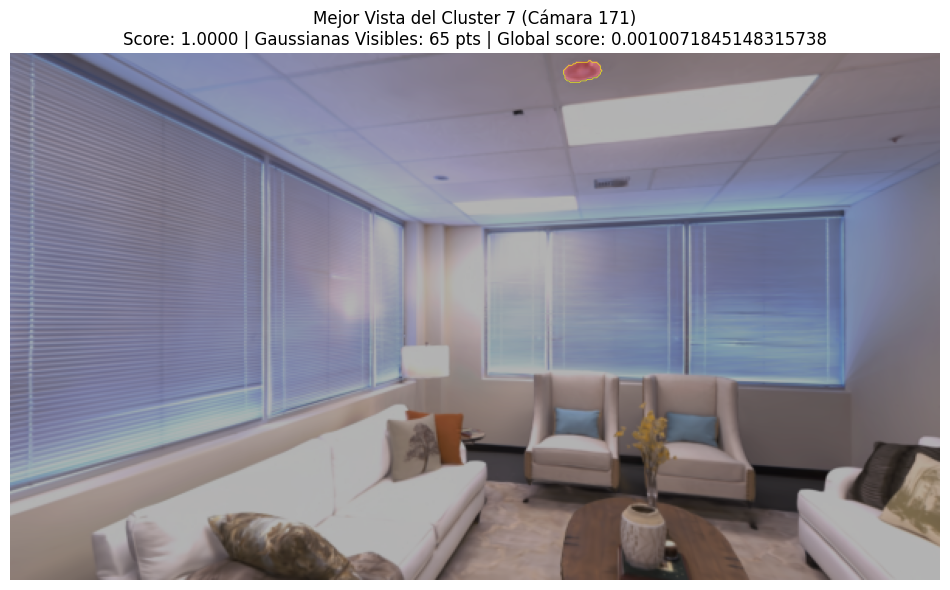

In [18]:
render_best_view_of_instance("7", render_params, setup_params, labels)

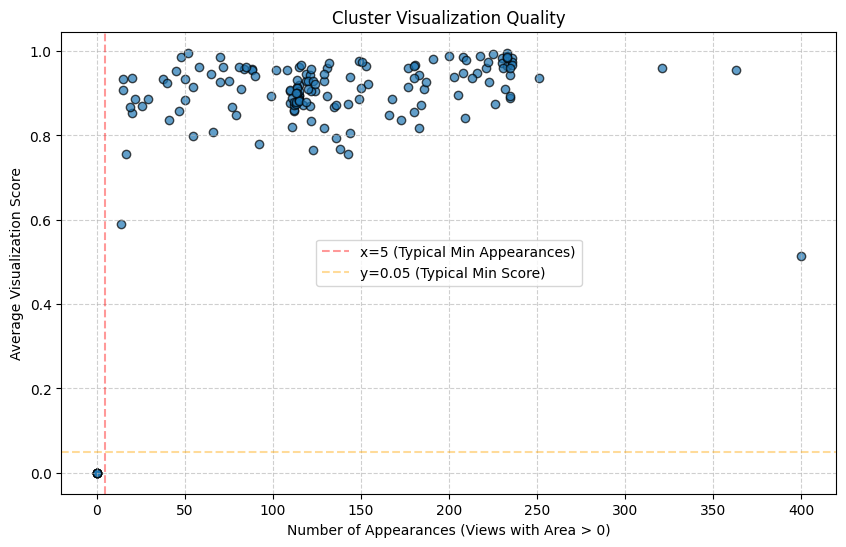

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(app_list_topk, rel_list_topk, alpha=0.7, edgecolors='k')

plt.title("Cluster Visualization Quality")
plt.xlabel("Number of Appearances (Views with Area > 0)")
plt.ylabel("Average Visualization Score")
plt.grid(True, linestyle='--', alpha=0.6)
    
# Optional styling to help visualize common thresholds
plt.axvline(x=5, color='r', linestyle='--', alpha=0.4, label='x=5 (Typical Min Appearances)')
plt.axhline(y=0.05, color='orange', linestyle='--', alpha=0.4, label='y=0.05 (Typical Min Score)')
plt.legend()

plt.show()

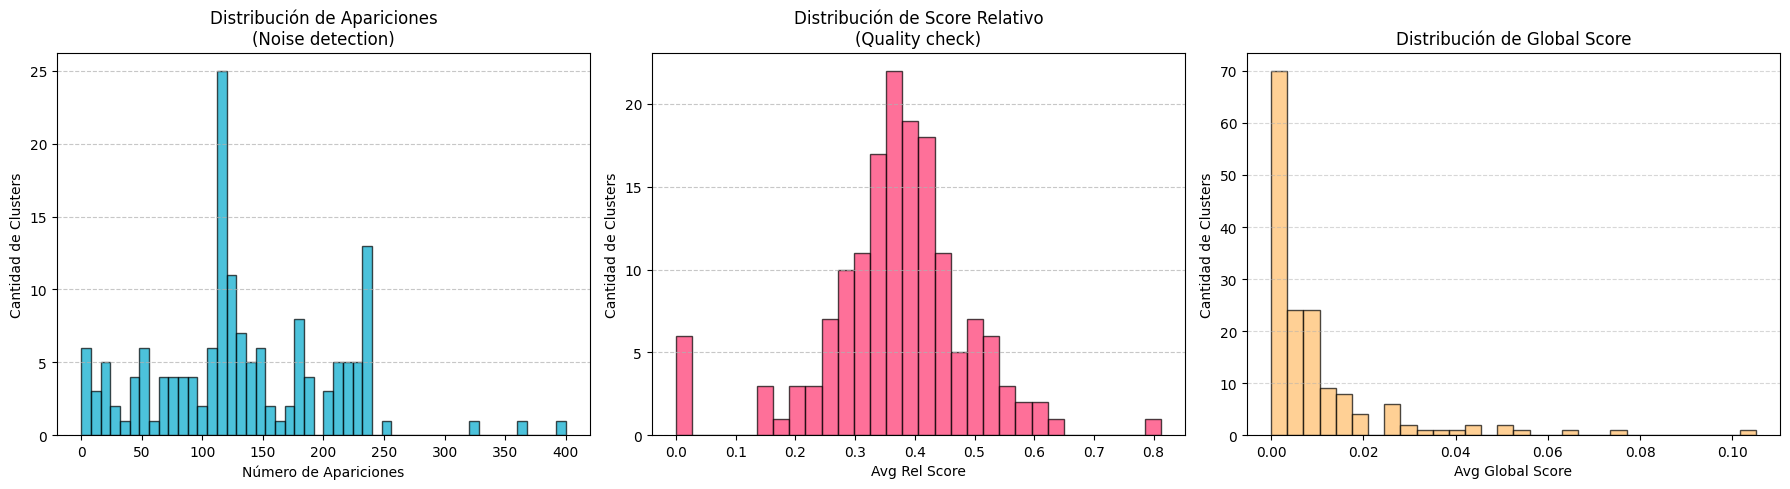

In [16]:
def plot_distributions(df):
    plt.figure(figsize=(18, 5))
    
    # Histograma de Apariciones
    plt.subplot(1, 3, 1)
    plt.hist(df['appearances'], bins=50, color='#00a8cc', edgecolor='black', alpha=0.7)
    plt.title('Distribución de Apariciones\n(Noise detection)')
    plt.xlabel('Número de Apariciones')
    plt.ylabel('Cantidad de Clusters')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Histograma de Score Relativo
    plt.subplot(1, 3, 2)
    plt.hist(df['avg_rel_score'], bins=30, color='#fe346e', edgecolor='black', alpha=0.7)
    plt.title('Distribución de Score Relativo\n(Quality check)')
    plt.xlabel('Avg Rel Score')
    plt.ylabel('Cantidad de Clusters')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.subplot(1, 3, 3)
    plt.hist(df['avg_global_score'], bins=30, color='#ffbd69', edgecolor='black', alpha=0.7)
    #plt.xscale('log')
    plt.title('Distribución de Global Score')
    plt.xlabel('Avg Global Score')
    plt.ylabel('Cantidad de Clusters')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
# Visualizar
plot_distributions(df_stats)

In [17]:
def filter_clusters_for_vlm(df, min_apps=5, min_rel_score=0.2, min_global_score=0.0002):
    """
    Separa clusters candidatos a objeto de aquellos que son ruido o inconsistentes.
    """
    df_valid = df[
        (df['appearances'] >= min_apps) & 
        (df['avg_rel_score'] >= min_rel_score) &
        (df['avg_global_score'] >= min_global_score)
    ].copy()
    
    df_noise = df[
        (df['appearances'] < min_apps) | 
        (df['avg_rel_score'] < min_rel_score) |
        (df['avg_global_score'] < min_global_score)
    ].copy()
    
    print(f"📊 Resumen de Filtrado:")
    print(f"----------------------")
    print(f"Items Totales    : {len(df)}")
    print(f"✅ Válidos (VLM) : {len(df_valid)} ({len(df_valid)/len(df)*100:.1f}%)")
    print(f"❌ Descartados   : {len(df_noise)} ({len(df_noise)/len(df)*100:.1f}%)")
    
    return df_valid.sort_values('avg_rel_score', ascending=False), df_noise

df_vlm, df_discarded = filter_clusters_for_vlm(df_stats, min_apps=5, min_rel_score=0.2)

print("\nTop 5 clusters candidatos a VLM:")
display(df_vlm.head())


📊 Resumen de Filtrado:
----------------------
Items Totales    : 158
✅ Válidos (VLM) : 145 (91.8%)
❌ Descartados   : 13 (8.2%)

Top 5 clusters candidatos a VLM:


,cluster_id,appearances,avg_rel_score,avg_global_score
7,7,15,0.812117,0.001007
5,5,48,0.633573,0.000618
136,136,225,0.617973,0.052125
20,20,29,0.612100,0.000480
141,141,233,0.586302,0.017897


In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

def plot_3d_filtering_contained(df, min_apps=5, min_rel=0.2, min_glob=0.0002):
    fig = plt.figure(figsize=(8, 6)) 

    fig.canvas.header_visible = False
    
    ax = fig.add_subplot(111, projection='3d')
    
    passed = (df['appearances'] >= min_apps) & \
             (df['avg_rel_score'] >= min_rel) & \
             (df['avg_global_score'] >= min_glob)
    
    x = df['appearances']
    y = df['avg_rel_score']
    z = np.log10(df['avg_global_score'].replace(0, 1e-9))
    
    ax.scatter(x[passed], y[passed], z[passed], c='#2ecc71', s=40, label='Candidatos VLM')
    ax.scatter(x[~passed], y[~passed], z[~passed], c='#e74c3c', s=10, alpha=0.1, label='Ruido')
    
    ax.set_xlabel('Appearances')
    ax.set_ylabel('Rel Score')
    ax.set_zlabel('Log10(Glob Score)')
    
    plt.tight_layout()
    plt.show()

plot_3d_filtering_contained(df_stats)
